# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import matplotlib
import seaborn
import plotly

print(pd.__version__)
print(matplotlib.__version__)
print(seaborn.__version__)
print(plotly.__version__)

!pip install plotly==6.1.1

In [ ]:
print(pd.__version__)
print(matplotlib.__version__)
print(seaborn.__version__)
print(plotly.__version__)


## Підготовка даних


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Data/yulu_bike_sharing_dataset.csv')

In [ ]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [ ]:
df.shape
print(df.shape)
df.head()

Набір даних містить 10886 рядків та 19 колонок.
Дані представлені з погодинною деталізацією, тобто кожен рядок відповідає одній годині оренди велосипедів.
Це дозволяє детально аналізувати зміни попиту з часом.Дані охоплюють період з 01.01.2011 по 31.12.2012 (2 роки).

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [ ]:
# Групуємо по даті та підсумовуємо кількість оренд
daily = df.groupby(df.index.date)['count'].sum()

# Перетворюємо індекс на datetime для коректного відображення на графіку
daily.index = pd.to_datetime(daily.index)

# Будуємо лінійний графік методом DataFrame.plot()
ax = daily.plot(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    grid=True,
    color='steelblue',
    linewidth=1.5,
    xlabel='Дата',
    ylabel='Кількість оренд'
)

Відповіді на питання для інтерпретації:
1. Чому графік має “заломи”?
Різкі перепади можуть виникати через погодні умови, свята або екстремальну температуру. Щоб прибрати — використати ковзне середнє: daily.rolling(7).mean().plot()
2. Загальні тенденції:
Кількість оренд зростає з 2011 до 2012 року — сервіс набирає популярність
3. Сезонні коливання:
Влітку (Q2/Q3) — більше оренд, взимку (Q1/Q4) — менше. Чітко виражена сезонність
4. Аномалії:
Різкі спади — шторми або свята. Різкі піки — спортивні події або особливо сприятлива погода


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [ ]:
import pandas as pd

# Словник для назв кварталів
quarter_names = {1: 'Q1 (Зима)', 2: 'Q2 (Весна)',
                 3: 'Q3 (Літо)', 4: 'Q4 (Осінь)'}

# Групуємо по кварталах та рахуємо середню кількість оренд
seasonal = df.groupby('season')['count'].mean()

# Замінюємо числа на назви кварталів
seasonal.index = seasonal.index.map(quarter_names)

# Будуємо стовпчасту діаграму
ax = seasonal.plot(
    kind='bar',
    figsize=(12, 6),
    title='Середня кількість оренд велосипедів за сезонами',
    color=['steelblue', 'green', 'orange', 'brown'],
    grid=True,
    xlabel='Сезон (квартал)',
    ylabel='Середня кількість оренд',
    rot=0  # горизонтальні підписи осі X
)

# Додаємо підписи значень над кожним стовпцем
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f'{bar.get_height():.0f}',
        ha='center', va='bottom', fontsize=11
    )


Відповіді на питання для інтерпретації:
 1. Найбільша середня кількість оренди велосипедів припадає на Q3 (Літо) — значення 234 оренди на годину.
 2. Така сезонна закономірність пояснюється тим, що влітку тепла та суха погода сприяє прогулянкам на велосипеді. Навесні (Q2) та восени (Q4) також досить комфортно — 215 та 199 відповідно. Взимку (Q1) холодна погода значно знижує попит — лише 116 оренд.
 3. Між найпопулярнішим кварталом Q3 (234) та найменш популярним Q1 (116) різниця становить приблизно 2 рази — літо вдвічі популярніше за зиму.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [ ]:
# Групуємо по місяцях та рахуємо середню кількість оренд
monthly = df.groupby('month')['count'].mean()

# Назви місяців для осі X
month_names = ['Січ', 'Лют', 'Бер', 'Кві', 'Тра', 'Чер',
               'Лип', 'Сер', 'Вер', 'Жов', 'Лис', 'Гру']

# Будуємо лінійний графік
ax = monthly.plot(
    kind='line',
    figsize=(12, 6),
    title='Середня кількість оренд велосипедів по місяцях',
    color='red',        # червона лінія
    marker='o',         # маркери-кружечки
    grid=True,
    ylabel='Середня кількість оренд',
    xlabel='Місяць'
)

# Встановлюємо 12 поділок по осі X з назвами місяців
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)

1. В які місяці спостерігається пік та спад оренди?
Пік — червень (~245), також високі значення в липні, серпні, вересні (~235-240). Спад — січень (~90) та лютий (~115) — найнижчі точки на графіку
2. Чи збігається з результатами Завдання 2?
Так, повністю збігається. У Завданні 2 Q3 (Літо) мав найвище значення 234 — і на цьому графіку червень-вересень є піковими місяцями. Q1 (Зима) мав найнижче значення 116 — і січень-лютий є найнижчими точками
3. Як може вплинути клімат на оренду велосипедів протягом року?
Графік чітко показує: з січня по червень оренда стабільно зростає разом з потеплінням. З жовтня по грудень падає разом з похолоданням. Це свідчить про пряму залежність між температурою та попитом на велосипеди

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

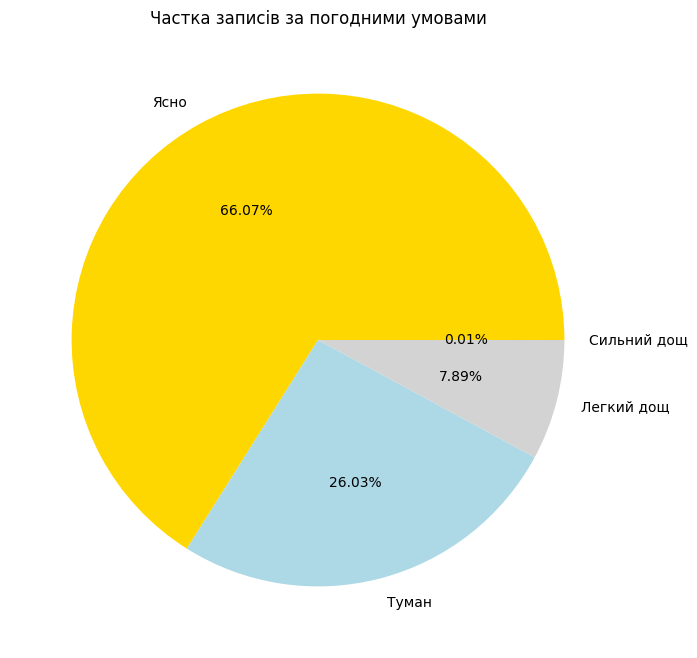

In [ ]:
# Словник з описами погоди
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

# Рахуємо кількість записів по кожній погодній умові
weather_counts = df['weather'].value_counts().sort_index()

# Замінюємо числа на описи
weather_counts.index = weather_counts.index.map(weather_labels)

# Будуємо кругову діаграму
weather_counts.plot(
    kind='pie',
    figsize=(8, 8),
    title='Частка записів за погодними умовами',
    autopct='%1.2f%%',        # підписи з відсотками
    colors=['gold', 'lightblue', 'lightgrey', 'tomato'],  # власні кольори
    ylabel=''                  # прибираємо стандартний підпис осі
)

1. Яка погода переважає в датасеті?
Ясна погода домінує — 66.07% всіх записів. Тобто 2 з 3 годин були з ясним небом
2. Чи є дні із сильним дощем? Яка їх частка?
Сильний дощ — лише 0.01%, тобто таких записів майже немає. Легкий дощ складає 7.89%
3. Як погодні умови впливають на попит на оренду велосипедів?
Оскільки 66.07% часу погода ясна, більшість оренд відбувається саме в такі дні. Туман (26.03%) помірно знижує попит, легкий дощ (7.89%) суттєво відлякує користувачів, а сильний дощ (0.01%) майже повністю зупиняє оренду

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [ ]:
import pandas as pd

# Словник з назвами погоди
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

# Замінюємо числа на назви погоди
df['weather_name'] = df['weather'].map(weather_labels)

# Групуємо дані по погоді для box plot
grouped = [df[df['weather_name'] == name]['count'].values
           for name in weather_labels.values()]

# Будуємо горизонтальний box plot
ax = df.boxplot(
    column='count',
    by='weather_name',
    figsize=(12, 6),
    vert=False          # горизонтальна орієнтація
)

# Заголовки та підписи
ax.set_title('Розподіл оренди велосипедів за погодними умовами')
ax.set_xlabel('Кількість оренд')
ax.set_ylabel('Погодні умови')

# Прибираємо автоматичний заголовок pandas
import matplotlib.pyplot as plt
plt.suptitle('')
plt.tight_layout()


1. При якій погоді найбільший розкид у кількості оренди?
Ясно — найширша коробка та найдовший вус, розкид сягає до ~1000 оренд
2. Чи є викиди (outliers)? При якій погоді?
Так, викиди є при всіх умовах крім сильного дощу:
 • Ясно — багато точок-викидів після 600
 • Туман — помітні викиди після 500
 • Легкий дощ — найбільше викидів відносно своєї коробки, точки розкидані аж до 1000
3. При якій погоді медіанне значення найвище?
Ясно та Туман мають схожі медіани (~150-200). Сильний дощ — медіана близька до 0, коробки майже не видно

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

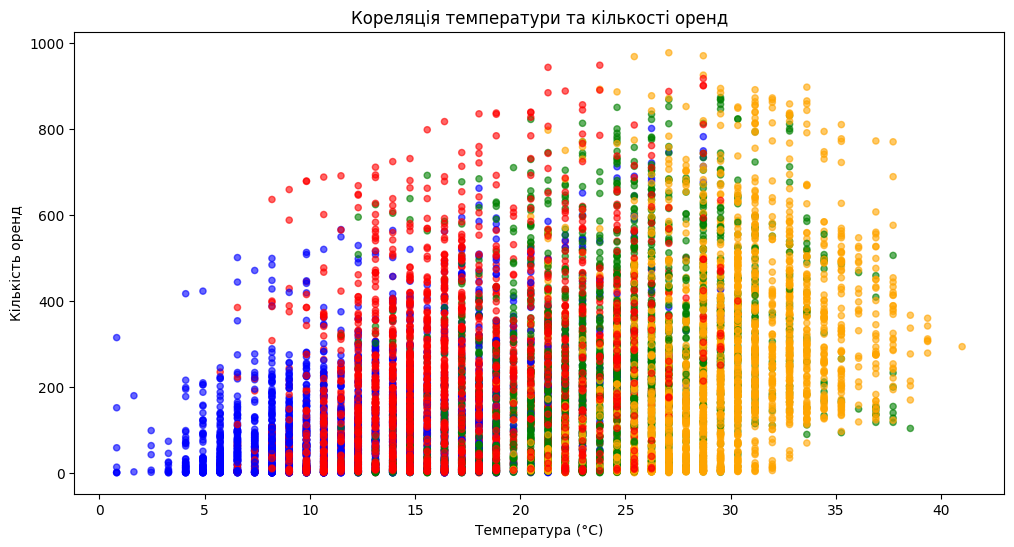

In [19]:
# Словник кольорів для сезонів
season_colors = {1: 'blue', 2: 'green', 3: 'orange', 4: 'red'}

# Будуємо scatter plot
ax = df.plot(
    kind='scatter',
    x='temp',
    y='count',
    c=df['season'].map(season_colors),
    alpha=0.6,
    figsize=(12, 6),
    title='Кореляція температури та кількості оренд',
    xlabel='Температура (°C)',
    ylabel='Кількість оренд'
)

Чи є зв’язок між температурою та кількістю оренди? Який?
Так, є чіткий позитивний зв’язок — з ростом температури кількість оренд зростає. При ~0-5°C оренди мінімальні (до 200), при ~25-35°C досягають максимуму (600-1000). Однак при температурі вище ~35-40°C оренда починає дещо спадати через надмірну спеку.
Також видно сезонність за кольорами: сині точки (Q1-Зима) концентруються зліва при низьких температурах, помаранчеві (Q3-Літо) — справа при високих. Це підтверджує пряму залежність між температурою, сезоном та попитом на велосипеди.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

<Axes: title={'center': 'Середня кількість оренд по днях тижня'}, xlabel='День тижня', ylabel='Середня кількість оренд'>

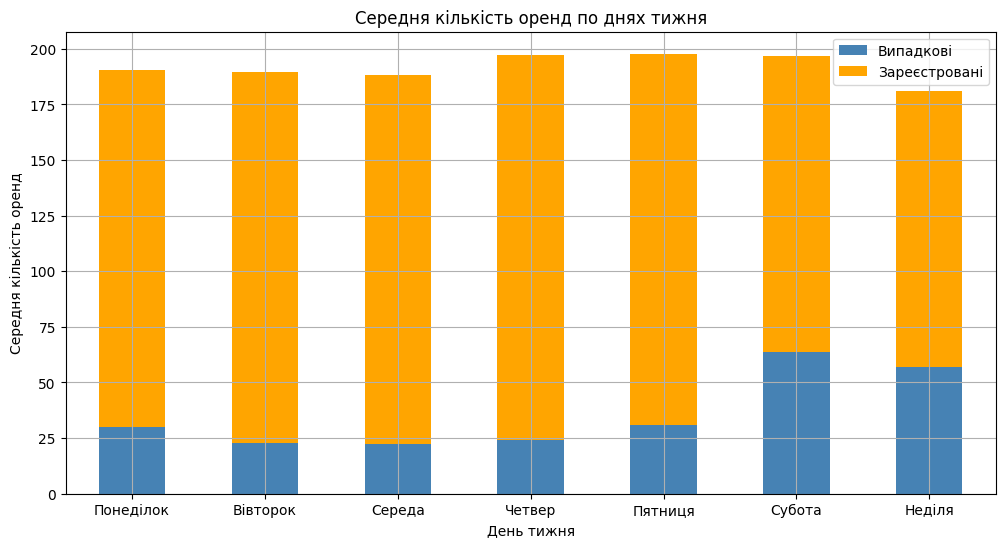

In [20]:
# Словник днів тижня
day_names = {
    0: 'Понеділок', 1: 'Вівторок', 2: 'Середа',
    3: 'Четвер', 4: 'Пятниця', 5: 'Субота', 6: 'Неділя'
}

# Групуємо по днях тижня та рахуємо середні значення
weekly = df.groupby('weekday_num')[['casual', 'registered']].mean()

# Замінюємо числа на назви днів
weekly.index = weekly.index.map(day_names)

# Перейменовуємо колонки для легенди
weekly.columns = ['Випадкові', 'Зареєстровані']

# Будуємо stacked bar chart
weekly.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    title='Середня кількість оренд по днях тижня',
    color=['steelblue', 'orange'],
    grid=True,
    xlabel='День тижня',
    ylabel='Середня кількість оренд',
    rot=0
)

1. В які дні більше оренд від зареєстрованих користувачів?
У всі робочі дні — Понеділок-П’ятниця. Помаранчева частина (зареєстровані) значно переважає і залишається стабільною ~160-175 у кожен робочий день
2. Як пояснити різницю в поведінці користувачів протягом тижня?
Графік чітко показує два патерни:
 • Робочі дні (Пн-Пт) — зареєстровані домінують (~160-175), випадкові мінімальні (~25). Зареєстровані використовують велосипед як регулярний транспорт на роботу
 • Вихідні (Сб-Нд) — зареєстровані падають, але випадкові різко зростають (~75-80). Люди орендують велосипеди для прогулянок та відпочинку